
# 04 Model Comparison

This notebook compares segmentation architectures using the split-aware combined manifest produced in Notebook 02 and the baseline reference established in Notebook 03.

Notebook 04 intentionally does **not** recreate manifests, splits, or data audits. It consumes:

- `data/processed/manifests/combined_segmentation_manifest_with_splits.csv`
- `reports/training/baseline_unet_resnet18_256px_5epoch_training_summary.csv`
- `reports/training/baseline_unet_resnet18_256px_5epoch_training_history.csv`

The first pass through this notebook performs setup, dataloader checks, model configuration, and forward-pass smoke tests. Controlled multi-epoch candidate training should only run after those checks pass.


In [18]:

# 04.01 — Imports

from __future__ import annotations

import inspect
import math
import os
import platform
import sys
import time
import warnings
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

warnings.filterwarnings(
    "ignore",
    message="IProgress not found.*",
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

print("Imports complete.")
print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")


Imports complete.
Python: 3.11.15
PyTorch: 2.4.0


In [19]:

# 04.02 — Project root and source path setup

def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root by walking upward until .git is found."""
    current = (start or Path.cwd()).resolve()

    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists():
            return candidate

    raise RuntimeError("Could not find project root. Run this notebook from inside the repository.")


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

os.chdir(PROJECT_ROOT)

setup_summary = pd.DataFrame(
    [
        {
            "project_root": str(PROJECT_ROOT),
            "src_dir": str(SRC_DIR),
            "src_on_path": str(SRC_DIR) in sys.path,
            "cwd": str(Path.cwd()),
        }
    ]
)

display(setup_summary)

assert PROJECT_ROOT.exists(), "Project root does not exist."
assert SRC_DIR.exists(), "src directory does not exist."
assert Path.cwd() == PROJECT_ROOT, "Working directory was not set to project root."


,project_root,src_dir,src_on_path,cwd
0,/sfs/gpfs/tardis/home/gsr3qz/Documents/MSDS/CA...,/sfs/gpfs/tardis/home/gsr3qz/Documents/MSDS/CA...,True,/sfs/gpfs/tardis/home/gsr3qz/Documents/MSDS/CA...


In [20]:

# 04.03 — Environment and phase-04 directory setup

REPORTS_TRAINING_DIR = PROJECT_ROOT / "reports" / "training"
REPORTS_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

REPORTS_TRAINING_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MODEL_COMPARISON_HISTORY_PATH = REPORTS_TRAINING_DIR / "model_comparison_training_history.csv"
MODEL_COMPARISON_SUMMARY_PATH = REPORTS_TRAINING_DIR / "model_comparison_summary.csv"

env_summary = {
    "python_version": sys.version.split()[0],
    "python_executable": sys.executable,
    "platform": platform.platform(),
    "torch_version": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_device_count": torch.cuda.device_count() if torch.cuda.is_available() else 0,
}

if torch.cuda.is_available():
    env_summary["cuda_device_name"] = torch.cuda.get_device_name(0)

display(pd.DataFrame([env_summary]).T.rename(columns={0: "value"}))

output_paths = pd.DataFrame(
    [
        {
            "artifact": "model comparison training history",
            "path": str(MODEL_COMPARISON_HISTORY_PATH.relative_to(PROJECT_ROOT)),
            "committable": True,
        },
        {
            "artifact": "model comparison summary",
            "path": str(MODEL_COMPARISON_SUMMARY_PATH.relative_to(PROJECT_ROOT)),
            "committable": True,
        },
    ]
)

display(output_paths)


,value
python_version,3.11.15
python_executable,/home/gsr3qz/.conda/envs/glaucoma-capstone/bin...
platform,Linux-4.18.0-553.124.1.el8_10.x86_64-x86_64-wi...
torch_version,2.4.0
cuda_available,True
cuda_device_count,1
cuda_device_name,NVIDIA RTX A6000


,artifact,path,committable
0,model comparison training history,reports/training/model_comparison_training_his...,True
1,model comparison summary,reports/training/model_comparison_summary.csv,True


In [21]:

# 04.04 — Input manifest and baseline handoff verification

MANIFEST_PATH = PROJECT_ROOT / "data" / "processed" / "manifests" / "combined_segmentation_manifest_with_splits.csv"
BASELINE_HISTORY_PATH = REPORTS_TRAINING_DIR / "baseline_unet_resnet18_256px_5epoch_training_history.csv"
BASELINE_SUMMARY_PATH = REPORTS_TRAINING_DIR / "baseline_unet_resnet18_256px_5epoch_training_summary.csv"

required_inputs = pd.DataFrame(
    [
        {
            "input_name": "combined split manifest",
            "path": str(MANIFEST_PATH.relative_to(PROJECT_ROOT)),
            "exists": MANIFEST_PATH.exists(),
        },
        {
            "input_name": "Notebook 03 baseline history",
            "path": str(BASELINE_HISTORY_PATH.relative_to(PROJECT_ROOT)),
            "exists": BASELINE_HISTORY_PATH.exists(),
        },
        {
            "input_name": "Notebook 03 baseline summary",
            "path": str(BASELINE_SUMMARY_PATH.relative_to(PROJECT_ROOT)),
            "exists": BASELINE_SUMMARY_PATH.exists(),
        },
    ]
)

display(required_inputs)

missing_inputs = required_inputs.loc[~required_inputs["exists"], "input_name"].tolist()
if missing_inputs:
    raise FileNotFoundError(f"Missing required Notebook 04 inputs: {missing_inputs}")

manifest = pd.read_csv(MANIFEST_PATH)
baseline_history = pd.read_csv(BASELINE_HISTORY_PATH)
baseline_summary = pd.read_csv(BASELINE_SUMMARY_PATH)

split_summary = (
    manifest["split"]
    .value_counts()
    .rename_axis("split")
    .reset_index(name="rows")
    .sort_values("split")
)

display(split_summary)

if "source_dataset" in manifest.columns:
    source_split_summary = (
        manifest.groupby(["source_dataset", "split"])
        .size()
        .reset_index(name="rows")
        .sort_values(["source_dataset", "split"])
    )
    display(source_split_summary)

display(baseline_summary)

baseline_best_loss = baseline_summary.loc[
    baseline_summary["summary_item"].eq("best_val_loss")
].copy()

if baseline_best_loss.empty:
    raise ValueError("Baseline summary does not contain a best_val_loss row.")

baseline_reference = baseline_best_loss.assign(
    comparison_role="Notebook 03 reference",
    model_name="unet",
    encoder_name="resnet18",
    encoder_weights="None",
    architecture_label="unet_resnet18",
)

print(
    "Baseline reference loaded from committed Notebook 03 outputs. "
    "Notebook 04 will not retrain the U-Net baseline unless explicitly changed."
)


,input_name,path,exists
0,combined split manifest,data/processed/manifests/combined_segmentation...,True
1,Notebook 03 baseline history,reports/training/baseline_unet_resnet18_256px_...,True
2,Notebook 03 baseline summary,reports/training/baseline_unet_resnet18_256px_...,True


,split,rows
2,test,722
0,train,1911
1,val,725


,source_dataset,split,rows
0,G1020,test,153
1,G1020,train,714
2,G1020,val,153
3,ORIGA,test,97
4,ORIGA,train,455
5,ORIGA,val,98
6,PAPILA,test,72
7,PAPILA,train,342
8,PAPILA,val,74
9,REFUGE,test,400


,run_name,summary_item,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds
0,baseline_unet_resnet18_256px_5epoch,best_val_loss,5,0.174628,0.811011,0.745284,0.097581,725,91,40.672631
1,baseline_unet_resnet18_256px_5epoch,best_val_cdr_mae,4,0.182682,0.809706,0.754545,0.077542,725,91,41.097457
2,baseline_unet_resnet18_256px_5epoch,final_train_epoch,5,0.166371,0.828955,0.740074,0.088787,1911,239,134.428963
3,baseline_unet_resnet18_256px_5epoch,final_val_epoch,5,0.174628,0.811011,0.745284,0.097581,725,91,40.672631


Baseline reference loaded from committed Notebook 03 outputs. Notebook 04 will not retrain the U-Net baseline unless explicitly changed.


In [22]:

# 04.05 — Core project module import check

from glaucoma_segmentation.data.dataloaders import make_segmentation_dataloaders
from glaucoma_segmentation.nets.model_factory import MODEL_ALIASES, MODEL_REGISTRY, build_model
from glaucoma_segmentation.nets.losses import DiceCELoss
from glaucoma_segmentation.training.train_loop import (
    extract_images_and_masks,
    fit_model_with_progress,
    history_to_dicts,
    model_forward,
)
from glaucoma_segmentation.utils.device import device_summary_dict, get_device
from glaucoma_segmentation.utils.seed import seed_everything

module_summary = pd.DataFrame(
    [
        {"component": "dataloaders", "object": "make_segmentation_dataloaders", "status": "OK"},
        {"component": "model factory", "object": "build_model", "status": "OK"},
        {"component": "losses", "object": "DiceCELoss", "status": "OK"},
        {"component": "training loop", "object": "fit_model_with_progress", "status": "OK"},
        {"component": "training loop", "object": "history_to_dicts", "status": "OK"},
        {"component": "training loop", "object": "model_forward", "status": "OK"},
        {"component": "runtime", "object": "get_device", "status": "OK"},
        {"component": "runtime", "object": "seed_everything", "status": "OK"},
    ]
)

display(module_summary)

signature_summary = pd.DataFrame(
    [
        {
            "object": "make_segmentation_dataloaders",
            "signature": str(inspect.signature(make_segmentation_dataloaders)),
        },
        {
            "object": "fit_model_with_progress",
            "signature": str(inspect.signature(fit_model_with_progress)),
        },
        {
            "object": "history_to_dicts",
            "signature": str(inspect.signature(history_to_dicts)),
        },
    ]
)

display(signature_summary)

registry_summary = pd.DataFrame(
    [
        {
            "registry_models": ", ".join(sorted(MODEL_REGISTRY)),
            "accepted_aliases": ", ".join(sorted(MODEL_ALIASES)),
        }
    ]
)

display(registry_summary)


,component,object,status
0,dataloaders,make_segmentation_dataloaders,OK
1,model factory,build_model,OK
2,losses,DiceCELoss,OK
3,training loop,fit_model_with_progress,OK
4,training loop,history_to_dicts,OK
5,training loop,model_forward,OK
6,runtime,get_device,OK
7,runtime,seed_everything,OK


,object,signature
0,make_segmentation_dataloaders,(manifest_path: 'str | Path' = 'data/processed...
1,fit_model_with_progress,"(model: 'torch.nn.Module', train_loader: 'Data..."
2,history_to_dicts,(history: 'list[EpochResult]') -> 'list[dict[s...


,registry_models,accepted_aliases
0,"deeplabv3plus, unet, unetplusplus","deeplabv3+, deeplabv3plus, unet, unet++, unetp..."


In [23]:

# 04.06 — Model comparison configuration

SEED = 42
N_CLASSES = 3

seed_config = seed_everything(
    seed=SEED,
    deterministic=False,
    cudnn_benchmark=True if torch.cuda.is_available() else None,
)

DEVICE = get_device()

IMAGE_SIZE = (256, 256)
BATCH_SIZE = 8 if DEVICE.type == "cuda" else 2
NUM_WORKERS = 1 if DEVICE.type == "cuda" else 0
PIN_MEMORY = DEVICE.type == "cuda"

VALIDATE_PATHS = True
VALIDATE_MASKS = False

CANDIDATE_EPOCHS = 5
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

MAX_TRAIN_BATCHES = None
MAX_VAL_BATCHES = None

config_summary = pd.DataFrame(
    [
        {
            "seed": SEED,
            "device": str(DEVICE),
            "image_size": str(IMAGE_SIZE),
            "batch_size": BATCH_SIZE,
            "num_workers": NUM_WORKERS,
            "pin_memory": PIN_MEMORY,
            "validate_paths": VALIDATE_PATHS,
            "validate_masks": VALIDATE_MASKS,
            "candidate_epochs": CANDIDATE_EPOCHS,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "max_train_batches": MAX_TRAIN_BATCHES,
            "max_val_batches": MAX_VAL_BATCHES,
        }
    ]
)

display(pd.DataFrame([seed_config.__dict__]))
display(pd.DataFrame([device_summary_dict(DEVICE)]))
display(config_summary)


,seed,deterministic,cudnn_benchmark
0,42,False,True


,device,device_type,name,cuda_available,cuda_device_count,mps_available
0,cuda,cuda,NVIDIA RTX A6000,True,1,False


,seed,device,image_size,batch_size,num_workers,pin_memory,validate_paths,validate_masks,candidate_epochs,learning_rate,weight_decay,max_train_batches,max_val_batches
0,42,cuda,"(256, 256)",8,1,True,True,False,5,0.0001,0.0001,None,None


In [24]:

# 04.07 — Build comparison dataloaders

dataloaders = make_segmentation_dataloaders(
    manifest_path=MANIFEST_PATH,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    num_workers=NUM_WORKERS,
    validate_paths=VALIDATE_PATHS,
    validate_masks=VALIDATE_MASKS,
    pin_memory=PIN_MEMORY,
)

if dataloaders.train is None or dataloaders.val is None or dataloaders.test is None:
    raise RuntimeError("Expected train, val, and test dataloaders to be available.")

loader_records = []

for split_name, loader in {
    "train": dataloaders.train,
    "val": dataloaders.val,
    "test": dataloaders.test,
}.items():
    loader_records.append(
        {
            "split": split_name,
            "dataset_rows": len(loader.dataset),
            "batches": len(loader),
            "batch_size": loader.batch_size,
            "num_workers": loader.num_workers,
            "pin_memory": loader.pin_memory,
        }
    )

loader_summary = pd.DataFrame(loader_records)
display(loader_summary)


,split,dataset_rows,batches,batch_size,num_workers,pin_memory
0,train,1911,239,8,1,True
1,val,725,91,8,1,True
2,test,722,91,8,1,True


In [25]:

# 04.08 — Inspect comparison batch

batch = next(iter(dataloaders.train))
images, masks = extract_images_and_masks(batch)

mask_unique_values = sorted(int(value) for value in torch.unique(masks).detach().cpu().tolist())

batch_summary = pd.DataFrame(
    [
        {
            "image_shape": str(tuple(images.shape)),
            "mask_shape": str(tuple(masks.shape)),
            "image_dtype": str(images.dtype),
            "mask_dtype": str(masks.dtype),
            "image_min": float(images.min()),
            "image_max": float(images.max()),
            "mask_values": str(mask_unique_values),
        }
    ]
)

display(batch_summary)

sample_paths = pd.DataFrame(
    {
        "image_path": list(batch.get("image_path", []))[:3],
        "mask_path": list(batch.get("mask_path", []))[:3],
    }
)

display(sample_paths)

assert images.ndim == 4 and images.shape[1] == 3, "Expected images with shape (B, 3, H, W)."
assert masks.ndim == 3, "Expected masks with shape (B, H, W)."
assert images.shape[-2:] == masks.shape[-2:], "Image and mask spatial dimensions must match."
assert set(mask_unique_values).issubset({0, 1, 2}), f"Unexpected mask values: {mask_unique_values}"


,image_shape,mask_shape,image_dtype,mask_dtype,image_min,image_max,mask_values
0,"(8, 3, 256, 256)","(8, 256, 256)",torch.float32,torch.int64,0.0,1.0,"[0, 1, 2]"


,image_path,mask_path
0,/sfs/gpfs/tardis/home/gsr3qz/Documents/MSDS/CA...,/sfs/gpfs/tardis/home/gsr3qz/Documents/MSDS/CA...
1,/sfs/gpfs/tardis/home/gsr3qz/Documents/MSDS/CA...,/sfs/gpfs/tardis/home/gsr3qz/Documents/MSDS/CA...
2,/sfs/gpfs/tardis/home/gsr3qz/Documents/MSDS/CA...,/sfs/gpfs/tardis/home/gsr3qz/Documents/MSDS/CA...


In [26]:

# 04.09 — Define candidate model configurations

baseline_plan_row = {
    "run_name": "baseline_unet_resnet18_256px_5epoch",
    "model_name": "unet",
    "encoder_name": "resnet18",
    "encoder_weights": "None",
    "classes": N_CLASSES,
    "image_size": str(IMAGE_SIZE),
    "epochs": 5,
    "comparison_role": "Notebook 03 reference only",
    "will_train_in_notebook_04": False,
}

candidate_configs = [
    {
        "run_name": f"model_compare_unetplusplus_resnet18_256px_{CANDIDATE_EPOCHS}epoch",
        "model_name": "unetplusplus",
        "encoder_name": "resnet18",
        "encoder_weights": None,
        "classes": N_CLASSES,
        "image_size": IMAGE_SIZE,
        "epochs": CANDIDATE_EPOCHS,
        "comparison_role": "Notebook 04 candidate",
    },
    {
        "run_name": f"model_compare_deeplabv3plus_resnet18_256px_{CANDIDATE_EPOCHS}epoch",
        "model_name": "deeplabv3plus",
        "encoder_name": "resnet18",
        "encoder_weights": None,
        "classes": N_CLASSES,
        "image_size": IMAGE_SIZE,
        "epochs": CANDIDATE_EPOCHS,
        "comparison_role": "Notebook 04 candidate",
    },
]

candidate_df = pd.DataFrame(candidate_configs)
candidate_display = candidate_df.copy()
candidate_display["encoder_weights"] = candidate_display["encoder_weights"].astype(str)
candidate_display["image_size"] = candidate_display["image_size"].astype(str)
candidate_display["will_train_in_notebook_04"] = True

model_plan = pd.concat(
    [
        pd.DataFrame([baseline_plan_row]),
        candidate_display[
            [
                "run_name",
                "model_name",
                "encoder_name",
                "encoder_weights",
                "classes",
                "image_size",
                "epochs",
                "comparison_role",
                "will_train_in_notebook_04",
            ]
        ],
    ],
    ignore_index=True,
)

display(model_plan)

if candidate_df["run_name"].duplicated().any():
    raise ValueError("Candidate run names must be unique.")


,run_name,model_name,encoder_name,encoder_weights,classes,image_size,epochs,comparison_role,will_train_in_notebook_04
0,baseline_unet_resnet18_256px_5epoch,unet,resnet18,None,3,"(256, 256)",5,Notebook 03 reference only,False
1,model_compare_unetplusplus_resnet18_256px_5epoch,unetplusplus,resnet18,NaN,3,"(256, 256)",5,Notebook 04 candidate,True
2,model_compare_deeplabv3plus_resnet18_256px_5epoch,deeplabv3plus,resnet18,NaN,3,"(256, 256)",5,Notebook 04 candidate,True


In [27]:

# 04.10 — Model construction and forward-pass smoke test

def count_model_parameters(model: torch.nn.Module) -> dict[str, int]:
    """Return trainable and total parameter counts for a PyTorch model."""
    trainable_params = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
    total_params = sum(parameter.numel() for parameter in model.parameters())

    return {
        "trainable_parameters": int(trainable_params),
        "total_parameters": int(total_params),
    }


criterion = DiceCELoss().to(DEVICE)

smoke_batch_size = min(2, images.shape[0])
smoke_images = images[:smoke_batch_size].to(DEVICE).float()
smoke_masks = masks[:smoke_batch_size].to(DEVICE).long()

smoke_records: list[dict[str, Any]] = []

for config in candidate_configs:
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    seed_everything(seed=SEED, deterministic=False)

    label = f"{config['model_name']}::{config['encoder_name']}"
    start_time = time.perf_counter()

    model = build_model(
        model_name=config["model_name"],
        encoder_name=config["encoder_name"],
        encoder_weights=config["encoder_weights"],
        in_channels=3,
        classes=config["classes"],
        activation=None,
    ).to(DEVICE)

    model.eval()
    parameter_counts = count_model_parameters(model)

    with torch.no_grad():
        logits = model_forward(model, smoke_images)
        loss = criterion(logits, smoke_masks)

    elapsed_seconds = time.perf_counter() - start_time
    expected_shape = (
        smoke_images.shape[0],
        N_CLASSES,
        smoke_images.shape[-2],
        smoke_images.shape[-1],
    )

    peak_memory_mb = np.nan
    if DEVICE.type == "cuda":
        peak_memory_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

    record = {
        "run_name": config["run_name"],
        "model_name": config["model_name"],
        "encoder_name": config["encoder_name"],
        "encoder_weights": str(config["encoder_weights"]),
        "logits_shape": str(tuple(logits.shape)),
        "expected_shape": str(expected_shape),
        "logits_shape_ok": tuple(logits.shape) == expected_shape,
        "finite_loss": bool(torch.isfinite(loss).detach().cpu().item()),
        "smoke_loss": float(loss.detach().cpu()),
        "construction_seconds": elapsed_seconds,
        "peak_memory_mb": peak_memory_mb,
        **parameter_counts,
    }

    smoke_records.append(record)

    del model, logits

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

smoke_df = pd.DataFrame(smoke_records)
display(smoke_df)

if not smoke_df["logits_shape_ok"].all():
    raise RuntimeError("At least one candidate produced an unexpected logits shape.")

if not smoke_df["finite_loss"].all():
    raise RuntimeError("At least one candidate produced a non-finite smoke-test loss.")


,run_name,model_name,encoder_name,encoder_weights,logits_shape,expected_shape,logits_shape_ok,finite_loss,smoke_loss,construction_seconds,peak_memory_mb,trainable_parameters,total_parameters
0,model_compare_unetplusplus_resnet18_256px_5epoch,unetplusplus,resnet18,None,"(2, 3, 256, 256)","(2, 3, 256, 256)",True,True,2.044991,0.311130,188.457031,15970739,15970739
1,model_compare_deeplabv3plus_resnet18_256px_5epoch,deeplabv3plus,resnet18,None,"(2, 3, 256, 256)","(2, 3, 256, 256)",True,True,1.911664,0.227209,101.233887,12329811,12329811


In [28]:

# 04.11 — Pre-training validation summary

candidate_checks_ready = bool(
    smoke_df["logits_shape_ok"].all()
    and smoke_df["finite_loss"].all()
)

pretraining_validation_summary = pd.DataFrame(
    [
        {
            "checkpoint": "Notebook 04 pre-training validation",
            "status": "READY" if candidate_checks_ready else "BLOCKED",
            "completed_checks": (
                "project setup, input verification, module imports, dataloaders, "
                "batch inspection, candidate configuration, and model forward-pass checks"
            ),
            "training_decision": (
                "Proceed with controlled candidate training using the shared "
                "Notebook 03 baseline configuration."
            ),
        }
    ]
)

display(pretraining_validation_summary)

if not candidate_checks_ready:
    raise RuntimeError("Notebook 04 pre-training validation did not pass.")

print("Notebook 04 pre-training validation passed.")


,checkpoint,status,completed_checks,training_decision
0,Notebook 04 pre-training validation,READY,"project setup, input verification, module impo...",Proceed with controlled candidate training usi...


Notebook 04 pre-training validation passed.


In [12]:

# 04.12 — Controlled candidate training setup

candidate_training_plan = candidate_df.copy()
candidate_training_plan["encoder_weights"] = candidate_training_plan["encoder_weights"].astype(str)
candidate_training_plan["image_size"] = candidate_training_plan["image_size"].astype(str)
candidate_training_plan["batch_size"] = BATCH_SIZE
candidate_training_plan["num_workers"] = NUM_WORKERS
candidate_training_plan["learning_rate"] = LEARNING_RATE
candidate_training_plan["weight_decay"] = WEIGHT_DECAY
candidate_training_plan["max_train_batches"] = MAX_TRAIN_BATCHES
candidate_training_plan["max_val_batches"] = MAX_VAL_BATCHES

candidate_parameter_summary = smoke_df[
    [
        "run_name",
        "trainable_parameters",
        "total_parameters",
        "peak_memory_mb",
    ]
].copy()

display(candidate_training_plan)
display(candidate_parameter_summary)

expected_training_epochs = int(candidate_training_plan["epochs"].sum())
expected_train_passes = len(candidate_training_plan)

training_readiness = pd.DataFrame(
    [
        {
            "ready_for_training": True,
            "candidate_models": expected_train_passes,
            "total_candidate_epochs": expected_training_epochs,
            "train_batches_per_epoch": len(dataloaders.train),
            "val_batches_per_epoch": len(dataloaders.val),
            "device": str(DEVICE),
            "note": (
                "This cell only defines the training plan. "
                "The next cell runs 5 epochs for each Notebook 04 candidate."
            ),
        }
    ]
)

display(training_readiness)


,run_name,model_name,encoder_name,encoder_weights,classes,image_size,epochs,comparison_role,batch_size,num_workers,learning_rate,weight_decay,max_train_batches,max_val_batches
0,model_compare_unetplusplus_resnet18_256px_5epoch,unetplusplus,resnet18,NaN,3,"(256, 256)",5,Notebook 04 candidate,8,1,0.0001,0.0001,None,None
1,model_compare_deeplabv3plus_resnet18_256px_5epoch,deeplabv3plus,resnet18,NaN,3,"(256, 256)",5,Notebook 04 candidate,8,1,0.0001,0.0001,None,None


,run_name,trainable_parameters,total_parameters,peak_memory_mb
0,model_compare_unetplusplus_resnet18_256px_5epoch,15970739,15970739,257.456543
1,model_compare_deeplabv3plus_resnet18_256px_5epoch,12329811,12329811,126.358887


,ready_for_training,candidate_models,total_candidate_epochs,train_batches_per_epoch,val_batches_per_epoch,device,note
0,True,2,10,239,91,cuda,This cell only defines the training plan. The ...


In [13]:

# 04.13 — Run controlled candidate training with progress

def _existing_run_is_complete(
    history_frame: pd.DataFrame,
    run_name: str,
    expected_epochs: int,
) -> bool:
    """Return True when an existing history CSV contains all train/val epochs for a run."""
    if history_frame.empty or "run_name" not in history_frame.columns:
        return False

    run_rows = history_frame.loc[history_frame["run_name"].eq(run_name)].copy()
    if run_rows.empty:
        return False

    expected = set(range(1, expected_epochs + 1))

    train_epochs = set(
        run_rows.loc[run_rows["phase"].eq("train"), "epoch"].dropna().astype(int).tolist()
    )
    val_epochs = set(
        run_rows.loc[run_rows["phase"].eq("val"), "epoch"].dropna().astype(int).tolist()
    )

    return expected.issubset(train_epochs) and expected.issubset(val_epochs)


def _load_existing_comparison_history() -> pd.DataFrame:
    """Load the model-comparison history CSV if it already exists."""
    if MODEL_COMPARISON_HISTORY_PATH.exists():
        return pd.read_csv(MODEL_COMPARISON_HISTORY_PATH)

    return pd.DataFrame()


def _save_or_replace_run_history(run_history: pd.DataFrame) -> None:
    """Save a run history, replacing prior rows for the same run name if present."""
    run_names = set(run_history["run_name"].unique().tolist())

    if MODEL_COMPARISON_HISTORY_PATH.exists():
        current_history = pd.read_csv(MODEL_COMPARISON_HISTORY_PATH)
        current_history = current_history.loc[~current_history["run_name"].isin(run_names)].copy()
        updated_history = pd.concat([current_history, run_history], ignore_index=True)
    else:
        updated_history = run_history.copy()

    updated_history = updated_history.sort_values(["run_name", "epoch", "phase"]).reset_index(drop=True)
    updated_history.to_csv(MODEL_COMPARISON_HISTORY_PATH, index=False)


run_runtime_records: list[dict[str, Any]] = []
existing_history = _load_existing_comparison_history()

for config in candidate_configs:
    run_name = config["run_name"]
    expected_epochs = int(config["epochs"])

    if _existing_run_is_complete(existing_history, run_name, expected_epochs):
        print(f"Skipping completed run already present in {MODEL_COMPARISON_HISTORY_PATH.name}: {run_name}")
        continue

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    seed_everything(
        seed=SEED,
        deterministic=False,
        cudnn_benchmark=True if DEVICE.type == "cuda" else None,
    )

    model = build_model(
        model_name=config["model_name"],
        encoder_name=config["encoder_name"],
        encoder_weights=config["encoder_weights"],
        in_channels=3,
        classes=config["classes"],
        activation=None,
    ).to(DEVICE)

    parameter_counts = count_model_parameters(model)

    criterion = DiceCELoss().to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    run_start = time.perf_counter()

    history = fit_model_with_progress(
        model=model,
        train_loader=dataloaders.train,
        val_loader=dataloaders.val,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        epochs=expected_epochs,
        max_train_batches=MAX_TRAIN_BATCHES,
        max_val_batches=MAX_VAL_BATCHES,
        run_name=run_name,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        print_epoch_summary=True,
        leave_progress=True,
    )

    total_run_seconds = time.perf_counter() - run_start

    run_history = pd.DataFrame(history_to_dicts(history))
    run_history.insert(0, "run_name", run_name)
    run_history.insert(1, "model_name", config["model_name"])
    run_history.insert(2, "encoder_name", config["encoder_name"])
    run_history.insert(3, "encoder_weights", str(config["encoder_weights"]))
    run_history.insert(4, "image_size", str(IMAGE_SIZE))
    run_history.insert(5, "batch_size", BATCH_SIZE)
    run_history.insert(6, "learning_rate", LEARNING_RATE)
    run_history.insert(7, "weight_decay", WEIGHT_DECAY)
    run_history.insert(8, "trainable_parameters", parameter_counts["trainable_parameters"])
    run_history.insert(9, "total_parameters", parameter_counts["total_parameters"])
    run_history.insert(10, "total_run_seconds", total_run_seconds)

    _save_or_replace_run_history(run_history)

    peak_memory_mb = np.nan
    if DEVICE.type == "cuda":
        peak_memory_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

    run_runtime_records.append(
        {
            "run_name": run_name,
            "model_name": config["model_name"],
            "encoder_name": config["encoder_name"],
            "epochs": expected_epochs,
            "total_run_seconds": total_run_seconds,
            "total_run_minutes": total_run_seconds / 60.0,
            "peak_memory_mb": peak_memory_mb,
            **parameter_counts,
        }
    )

    model.to("cpu")
    del model, criterion, optimizer, history

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    existing_history = _load_existing_comparison_history()

comparison_history = _load_existing_comparison_history()

display(pd.DataFrame(run_runtime_records))
display(comparison_history.tail(12))

if comparison_history.empty:
    raise RuntimeError("No model comparison history was generated.")

print(f"Saved candidate training history to: {MODEL_COMPARISON_HISTORY_PATH.relative_to(PROJECT_ROOT)}")


Running model_compare_unetplusplus_resnet18_256px_5epoch | epoch 01/05 | image_size=(256, 256) | batch_size=8


val epoch 01/05: 100%|██████████| 91/91 [00:55<00:00,  1.64it/s, loss=0.8485, disc=0.715, cup=0.685, cdr_mae=0.369]


Epoch 01/05 complete | train_loss=1.3329 | val_loss=0.8485 | val_disc_dice=0.7149 | val_cup_dice=0.6846 | val_cdr_mae=0.3693 | epoch_time=4.00 min
Running model_compare_unetplusplus_resnet18_256px_5epoch | epoch 02/05 | image_size=(256, 256) | batch_size=8


val epoch 02/05: 100%|██████████| 91/91 [00:41<00:00,  2.17it/s, loss=0.5130, disc=0.755, cup=0.719, cdr_mae=0.106]


Epoch 02/05 complete | train_loss=0.6600 | val_loss=0.5130 | val_disc_dice=0.7548 | val_cup_dice=0.7187 | val_cdr_mae=0.1055 | epoch_time=3.08 min
Running model_compare_unetplusplus_resnet18_256px_5epoch | epoch 03/05 | image_size=(256, 256) | batch_size=8


...

val epoch 05/05: 100%|██████████| 91/91 [00:39<00:00,  2.30it/s, loss=0.1864, disc=0.773, cup=0.745, cdr_mae=0.080]

Epoch 05/05 complete | train_loss=0.1738 | val_loss=0.1864 | val_disc_dice=0.7733 | val_cup_dice=0.7450 | val_cdr_mae=0.0796 | epoch_time=2.98 min


,run_name,model_name,encoder_name,epochs,total_run_seconds,total_run_minutes,peak_memory_mb,trainable_parameters,total_parameters
0,model_compare_unetplusplus_resnet18_256px_5epoch,unetplusplus,resnet18,5,986.411961,16.440199,9722.014160,15970739,15970739
1,model_compare_deeplabv3plus_resnet18_256px_5epoch,deeplabv3plus,resnet18,5,914.838016,15.247300,3104.132812,12329811,12329811


,run_name,model_name,encoder_name,encoder_weights,image_size,batch_size,learning_rate,weight_decay,trainable_parameters,total_parameters,total_run_seconds,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches
8,model_compare_deeplabv3plus_resnet18_256px_5epoch,deeplabv3plus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,12329811,12329811,914.838016,train,5,0.173847,0.809466,0.722552,0.093595,1911,239,139.137904,NaN
9,model_compare_deeplabv3plus_resnet18_256px_5epoch,deeplabv3plus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,12329811,12329811,914.838016,val,5,0.186362,0.773322,0.744973,0.079551,725,91,39.589662,NaN
10,model_compare_unetplusplus_resnet18_256px_5epoch,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,15970739,15970739,986.411961,train,1,1.332940,0.416701,0.363448,0.432590,1911,239,184.734337,NaN
11,model_compare_unetplusplus_resnet18_256px_5epoch,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,15970739,15970739,986.411961,val,1,0.848464,0.714930,0.684556,0.369322,725,91,55.498844,NaN
12,model_compare_unetplusplus_resnet18_256px_5epoch,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,15970739,15970739,986.411961,train,2,0.659996,0.728294,0.652600,0.192859,1911,239,142.620716,NaN
13,model_compare_unetplusplus_resnet18_256px_5epoch,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,15970739,15970739,986.411961,val,2,0.512977,0.754779,0.718691,0.105511,725,91,41.887414,NaN
14,model_compare_unetplusplus_resnet18_256px_5epoch,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,15970739,15970739,986.411961,train,3,0.377814,0.769753,0.682624,0.112211,1911,239,146.320504,NaN
15,model_compare_unetplusplus_resnet18_256px_5epoch,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,15970739,15970739,986.411961,val,3,0.299333,0.761181,0.732646,0.081575,725,91,41.443926,NaN
16,model_compare_unetplusplus_resnet18_256px_5epoch,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,15970739,15970739,986.411961,train,4,0.235001,0.809865,0.719742,0.097486,1911,239,146.000246,NaN
17,model_compare_unetplusplus_resnet18_256px_5epoch,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,15970739,15970739,986.411961,val,4,0.210272,0.811452,0.754761,0.086334,725,91,41.072131,NaN


Saved candidate training history to: reports/training/model_comparison_training_history.csv


In [14]:

# 04.14 — Save model comparison summary outputs

def _history_with_run_name(history_frame: pd.DataFrame, run_name: str) -> pd.DataFrame:
    """Ensure a training-history dataframe has a run_name column."""
    prepared = history_frame.copy()

    if "run_name" not in prepared.columns:
        prepared.insert(0, "run_name", run_name)
    else:
        prepared["run_name"] = prepared["run_name"].fillna(run_name)

    return prepared


def _summarize_training_history(
    history_frame: pd.DataFrame,
    run_metadata: dict[str, Any],
) -> dict[str, Any]:
    """Create a one-row summary from train/validation history."""
    history_frame = history_frame.copy()

    train_rows = history_frame.loc[history_frame["phase"].eq("train")].sort_values("epoch")
    val_rows = history_frame.loc[history_frame["phase"].eq("val")].sort_values("epoch")

    if train_rows.empty:
        raise ValueError(f"No train rows found for {run_metadata['run_name']!r}.")
    if val_rows.empty:
        raise ValueError(f"No validation rows found for {run_metadata['run_name']!r}.")

    best_loss_row = val_rows.loc[val_rows["loss"].idxmin()]
    best_cdr_row = val_rows.loc[val_rows["cdr_mae"].idxmin()]
    final_train_row = train_rows.iloc[-1]
    final_val_row = val_rows.iloc[-1]

    total_train_seconds = float(train_rows["elapsed_seconds"].sum())
    total_val_seconds = float(val_rows["elapsed_seconds"].sum())

    return {
        **run_metadata,
        "epochs_trained": int(val_rows["epoch"].max()),
        "best_epoch_by_val_loss": int(best_loss_row["epoch"]),
        "best_val_loss": float(best_loss_row["loss"]),
        "best_val_loss_disc_dice": float(best_loss_row["disc_dice"]),
        "best_val_loss_cup_dice": float(best_loss_row["cup_dice"]),
        "best_val_loss_cdr_mae": float(best_loss_row["cdr_mae"]),
        "best_epoch_by_val_cdr_mae": int(best_cdr_row["epoch"]),
        "best_val_cdr_mae": float(best_cdr_row["cdr_mae"]),
        "best_cdr_mae_val_loss": float(best_cdr_row["loss"]),
        "best_cdr_mae_disc_dice": float(best_cdr_row["disc_dice"]),
        "best_cdr_mae_cup_dice": float(best_cdr_row["cup_dice"]),
        "final_train_loss": float(final_train_row["loss"]),
        "final_train_disc_dice": float(final_train_row["disc_dice"]),
        "final_train_cup_dice": float(final_train_row["cup_dice"]),
        "final_train_cdr_mae": float(final_train_row["cdr_mae"]),
        "final_val_loss": float(final_val_row["loss"]),
        "final_val_disc_dice": float(final_val_row["disc_dice"]),
        "final_val_cup_dice": float(final_val_row["cup_dice"]),
        "final_val_cdr_mae": float(final_val_row["cdr_mae"]),
        "total_train_seconds": total_train_seconds,
        "total_val_seconds": total_val_seconds,
        "total_fit_seconds": total_train_seconds + total_val_seconds,
        "total_fit_minutes": (total_train_seconds + total_val_seconds) / 60.0,
    }


baseline_run_name = "baseline_unet_resnet18_256px_5epoch"
baseline_history_for_summary = _history_with_run_name(baseline_history, baseline_run_name)

baseline_param_model = build_model(
    model_name="unet",
    encoder_name="resnet18",
    encoder_weights=None,
    in_channels=3,
    classes=N_CLASSES,
    activation=None,
)
baseline_parameter_counts = count_model_parameters(baseline_param_model)
del baseline_param_model

summary_records: list[dict[str, Any]] = []

summary_records.append(
    _summarize_training_history(
        baseline_history_for_summary,
        {
            "run_name": baseline_run_name,
            "comparison_role": "Notebook 03 baseline reference",
            "model_name": "unet",
            "encoder_name": "resnet18",
            "encoder_weights": "None",
            "image_size": str(IMAGE_SIZE),
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            **baseline_parameter_counts,
        },
    )
)

comparison_history = pd.read_csv(MODEL_COMPARISON_HISTORY_PATH)

for config in candidate_configs:
    run_name = config["run_name"]
    run_history = comparison_history.loc[comparison_history["run_name"].eq(run_name)].copy()

    if run_history.empty:
        raise ValueError(f"No comparison-history rows found for {run_name!r}.")

    first_row = run_history.iloc[0]

    summary_records.append(
        _summarize_training_history(
            run_history,
            {
                "run_name": run_name,
                "comparison_role": "Notebook 04 candidate",
                "model_name": config["model_name"],
                "encoder_name": config["encoder_name"],
                "encoder_weights": str(config["encoder_weights"]),
                "image_size": str(IMAGE_SIZE),
                "batch_size": BATCH_SIZE,
                "learning_rate": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY,
                "trainable_parameters": int(first_row["trainable_parameters"]),
                "total_parameters": int(first_row["total_parameters"]),
            },
        )
    )

model_comparison_summary = pd.DataFrame(summary_records)
model_comparison_summary = model_comparison_summary.sort_values("best_val_loss").reset_index(drop=True)

model_comparison_summary.to_csv(MODEL_COMPARISON_SUMMARY_PATH, index=False)

display(model_comparison_summary)

print(f"Saved model comparison history to: {MODEL_COMPARISON_HISTORY_PATH.relative_to(PROJECT_ROOT)}")
print(f"Saved model comparison summary to: {MODEL_COMPARISON_SUMMARY_PATH.relative_to(PROJECT_ROOT)}")


,run_name,comparison_role,model_name,encoder_name,encoder_weights,image_size,batch_size,learning_rate,weight_decay,trainable_parameters,total_parameters,epochs_trained,best_epoch_by_val_loss,best_val_loss,best_val_loss_disc_dice,best_val_loss_cup_dice,best_val_loss_cdr_mae,best_epoch_by_val_cdr_mae,best_val_cdr_mae,best_cdr_mae_val_loss,best_cdr_mae_disc_dice,best_cdr_mae_cup_dice,final_train_loss,final_train_disc_dice,final_train_cup_dice,final_train_cdr_mae,final_val_loss,final_val_disc_dice,final_val_cup_dice,final_val_cdr_mae,total_train_seconds,total_val_seconds,total_fit_seconds,total_fit_minutes
0,baseline_unet_resnet18_256px_5epoch,Notebook 03 baseline reference,unet,resnet18,None,"(256, 256)",8,0.0001,0.0001,14328499,14328499,5,5,0.174628,0.811011,0.745284,0.097581,4,0.077542,0.182682,0.809706,0.754545,0.166371,0.828955,0.740074,0.088787,0.174628,0.811011,0.745284,0.097581,682.983765,208.607182,891.590947,14.859849
1,model_compare_unetplusplus_resnet18_256px_5epoch,Notebook 04 candidate,unetplusplus,resnet18,None,"(256, 256)",8,0.0001,0.0001,15970739,15970739,5,5,0.178129,0.819887,0.768749,0.086361,3,0.081575,0.299333,0.761181,0.732646,0.182391,0.830609,0.741439,0.088644,0.178129,0.819887,0.768749,0.086361,765.349136,221.030007,986.379143,16.439652
2,model_compare_deeplabv3plus_resnet18_256px_5epoch,Notebook 04 candidate,deeplabv3plus,resnet18,None,"(256, 256)",8,0.0001,0.0001,12329811,12329811,5,5,0.186362,0.773322,0.744973,0.079551,3,0.079487,0.202860,0.774550,0.747759,0.173847,0.809466,0.722552,0.093595,0.186362,0.773322,0.744973,0.079551,709.450954,205.367378,914.818332,15.246972


Saved model comparison history to: reports/training/model_comparison_training_history.csv
Saved model comparison summary to: reports/training/model_comparison_summary.csv


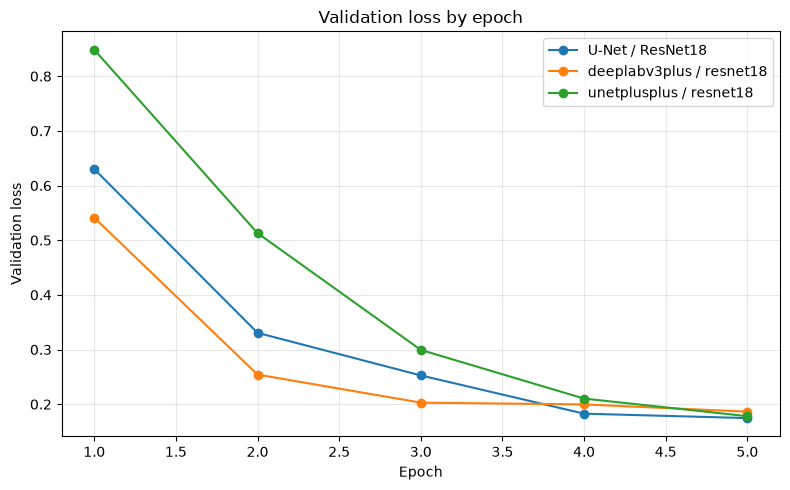

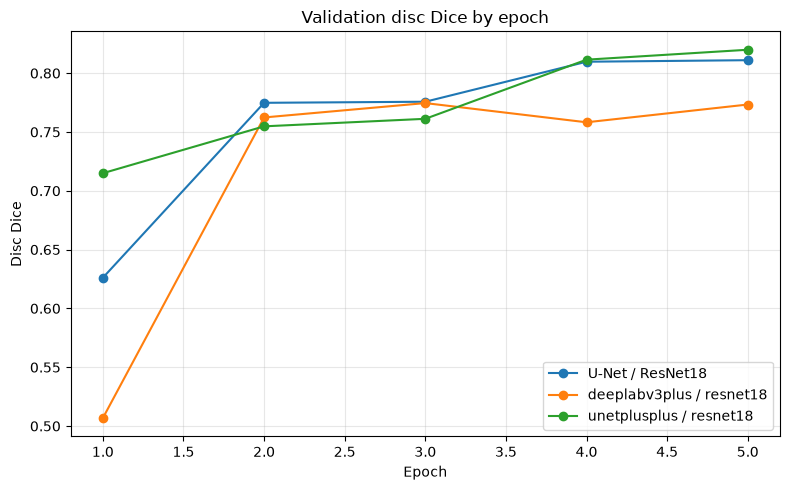

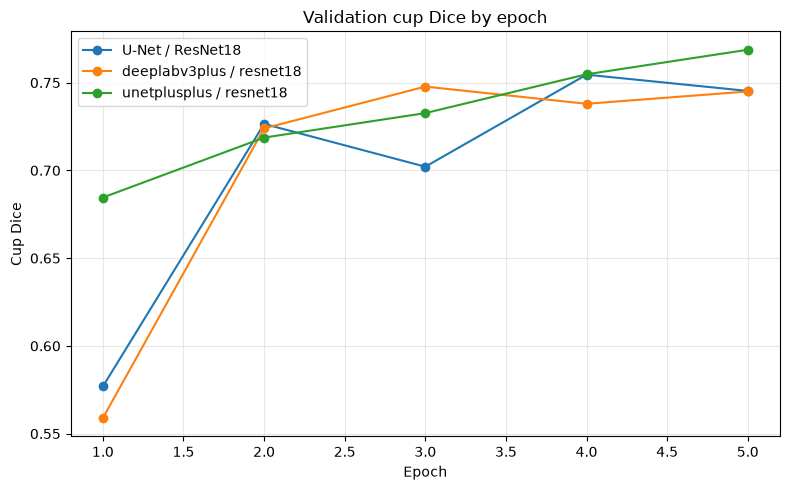

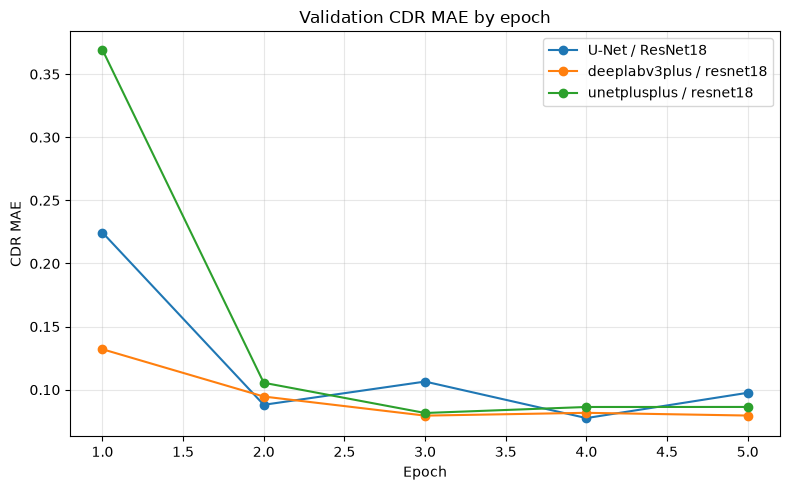

,metric,figure_path,note
0,loss,reports/figures/model_comparison_validation_lo...,PNG is expected to be ignored by .gitignore; n...
1,disc_dice,reports/figures/model_comparison_validation_di...,PNG is expected to be ignored by .gitignore; n...
2,cup_dice,reports/figures/model_comparison_validation_cu...,PNG is expected to be ignored by .gitignore; n...
3,cdr_mae,reports/figures/model_comparison_validation_cd...,PNG is expected to be ignored by .gitignore; n...


In [15]:

# 04.15 — Plot model comparison validation curves

baseline_plot_history = baseline_history_for_summary.copy()
baseline_plot_history["model_name"] = "unet"
baseline_plot_history["encoder_name"] = "resnet18"
baseline_plot_history["encoder_weights"] = "None"
baseline_plot_history["architecture_label"] = "U-Net / ResNet18"

candidate_plot_history = comparison_history.copy()
candidate_plot_history["architecture_label"] = (
    candidate_plot_history["model_name"].astype(str)
    + " / "
    + candidate_plot_history["encoder_name"].astype(str)
)

plot_history = pd.concat(
    [baseline_plot_history, candidate_plot_history],
    ignore_index=True,
    sort=False,
)

val_plot_history = plot_history.loc[plot_history["phase"].eq("val")].copy()

metric_specs = [
    ("loss", "Validation loss by epoch", "Validation loss", "model_comparison_validation_loss.png"),
    ("disc_dice", "Validation disc Dice by epoch", "Disc Dice", "model_comparison_validation_disc_dice.png"),
    ("cup_dice", "Validation cup Dice by epoch", "Cup Dice", "model_comparison_validation_cup_dice.png"),
    ("cdr_mae", "Validation CDR MAE by epoch", "CDR MAE", "model_comparison_validation_cdr_mae.png"),
]

figure_records = []

for metric_name, title, ylabel, filename in metric_specs:
    figure_path = REPORTS_FIGURES_DIR / filename

    plt.figure(figsize=(8, 5))

    for run_name, group in val_plot_history.groupby("run_name", sort=False):
        group = group.sort_values("epoch")
        label = group["architecture_label"].iloc[0]
        plt.plot(group["epoch"], group[metric_name], marker="o", label=label)

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(figure_path, dpi=150, bbox_inches="tight")
    plt.show()

    figure_records.append(
        {
            "metric": metric_name,
            "figure_path": str(figure_path.relative_to(PROJECT_ROOT)),
            "note": "PNG is expected to be ignored by .gitignore; notebook/HTML embeds the displayed figure.",
        }
    )

display(pd.DataFrame(figure_records))


In [17]:

# 04.16 — Notebook 04 model comparison handoff summary

best_by_val_loss = model_comparison_summary.loc[model_comparison_summary["best_val_loss"].idxmin()]
best_by_cdr_mae = model_comparison_summary.loc[model_comparison_summary["best_val_cdr_mae"].idxmin()]

baseline_summary_row = model_comparison_summary.loc[
    model_comparison_summary["comparison_role"].eq("Notebook 03 baseline reference")
].iloc[0]

candidate_summary_rows = model_comparison_summary.loc[
    model_comparison_summary["comparison_role"].eq("Notebook 04 candidate")
].copy()

best_candidate_by_loss = candidate_summary_rows.loc[candidate_summary_rows["best_val_loss"].idxmin()]
best_candidate_improved_loss = bool(
    best_candidate_by_loss["best_val_loss"] < baseline_summary_row["best_val_loss"]
)

best_candidate_by_cdr = candidate_summary_rows.loc[candidate_summary_rows["best_val_cdr_mae"].idxmin()]
best_candidate_improved_cdr = bool(
    best_candidate_by_cdr["best_val_cdr_mae"] < baseline_summary_row["best_val_cdr_mae"]
)

if best_candidate_improved_loss or best_candidate_improved_cdr:
    next_step_recommendation = (
        "Proceed to Notebook 05 augmentation/regularization using the strongest candidate architecture "
        "while keeping the Notebook 03 U-Net baseline as the reference."
    )
else:
    next_step_recommendation = (
        "Proceed to augmentation/regularization with the U-Net baseline as the conservative reference, "
        "and treat Notebook 04 candidates as architecture checks rather than replacements."
    )

handoff_summary = pd.DataFrame(
    [
        {
            "checkpoint": "Notebook 04 model comparison",
            "status": "READY",
            "best_by_val_loss": (
                f"{best_by_val_loss['model_name']} / {best_by_val_loss['encoder_name']} "
                f"epoch {int(best_by_val_loss['best_epoch_by_val_loss'])}"
            ),
            "best_val_loss": float(best_by_val_loss["best_val_loss"]),
            "best_by_cdr_mae": (
                f"{best_by_cdr_mae['model_name']} / {best_by_cdr_mae['encoder_name']} "
                f"epoch {int(best_by_cdr_mae['best_epoch_by_val_cdr_mae'])}"
            ),
            "best_val_cdr_mae": float(best_by_cdr_mae["best_val_cdr_mae"]),
            "candidate_improved_val_loss_vs_baseline": best_candidate_improved_loss,
            "candidate_improved_cdr_mae_vs_baseline": best_candidate_improved_cdr,
            "next_step_recommendation": next_step_recommendation,
        }
    ]
)

display(model_comparison_summary)
display(handoff_summary)


,run_name,comparison_role,model_name,encoder_name,encoder_weights,image_size,batch_size,learning_rate,weight_decay,trainable_parameters,total_parameters,epochs_trained,best_epoch_by_val_loss,best_val_loss,best_val_loss_disc_dice,best_val_loss_cup_dice,best_val_loss_cdr_mae,best_epoch_by_val_cdr_mae,best_val_cdr_mae,best_cdr_mae_val_loss,best_cdr_mae_disc_dice,best_cdr_mae_cup_dice,final_train_loss,final_train_disc_dice,final_train_cup_dice,final_train_cdr_mae,final_val_loss,final_val_disc_dice,final_val_cup_dice,final_val_cdr_mae,total_train_seconds,total_val_seconds,total_fit_seconds,total_fit_minutes
0,baseline_unet_resnet18_256px_5epoch,Notebook 03 baseline reference,unet,resnet18,None,"(256, 256)",8,0.0001,0.0001,14328499,14328499,5,5,0.174628,0.811011,0.745284,0.097581,4,0.077542,0.182682,0.809706,0.754545,0.166371,0.828955,0.740074,0.088787,0.174628,0.811011,0.745284,0.097581,682.983765,208.607182,891.590947,14.859849
1,model_compare_unetplusplus_resnet18_256px_5epoch,Notebook 04 candidate,unetplusplus,resnet18,None,"(256, 256)",8,0.0001,0.0001,15970739,15970739,5,5,0.178129,0.819887,0.768749,0.086361,3,0.081575,0.299333,0.761181,0.732646,0.182391,0.830609,0.741439,0.088644,0.178129,0.819887,0.768749,0.086361,765.349136,221.030007,986.379143,16.439652
2,model_compare_deeplabv3plus_resnet18_256px_5epoch,Notebook 04 candidate,deeplabv3plus,resnet18,None,"(256, 256)",8,0.0001,0.0001,12329811,12329811,5,5,0.186362,0.773322,0.744973,0.079551,3,0.079487,0.202860,0.774550,0.747759,0.173847,0.809466,0.722552,0.093595,0.186362,0.773322,0.744973,0.079551,709.450954,205.367378,914.818332,15.246972


,checkpoint,status,best_by_val_loss,best_val_loss,best_by_cdr_mae,best_val_cdr_mae,candidate_improved_val_loss_vs_baseline,candidate_improved_cdr_mae_vs_baseline,next_step_recommendation
0,Notebook 04 model comparison,READY,unet / resnet18 epoch 5,0.174628,unet / resnet18 epoch 4,0.077542,False,False,Proceed to augmentation/regularization with th...
